In [3]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize_scalar

C:\Users\thewe\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\thewe\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [6]:
df = pd.read_csv('dataset_produccion_s13.csv')
df

,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
0,L001,Abrazadera D,Tarde,114,1.95,204.4,37.8,8.0,222.30
1,L002,Válvula E,Tarde,306,2.83,230.8,56.8,11.0,865.98
2,L003,Tuerca C,Tarde,180,3.66,242.8,44.8,4.0,658.80
3,L004,Válvula E,Tarde,210,2.14,242.1,38.5,0.0,449.40
4,L005,Válvula E,Tarde,336,4.87,234.6,14.9,9.0,1636.32
5,L006,Perno B,Mañana,84,4.83,NaN,40.8,9.0,405.72
6,L007,Tuerca C,Noche,297,1.63,185.9,59.5,0.0,484.11
7,L008,Tuerca C,Tarde,334,2.74,191.3,17.0,14.0,915.16
8,L009,Tuerca C,Tarde,362,1.85,242.9,35.9,1.0,669.70
9,L010,Válvula E,Tarde,286,1.78,222.5,53.9,13.0,509.08


In [7]:
df.head(5)

,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
0,L001,Abrazadera D,Tarde,114,1.95,204.4,37.8,8.0,222.30
1,L002,Válvula E,Tarde,306,2.83,230.8,56.8,11.0,865.98
2,L003,Tuerca C,Tarde,180,3.66,242.8,44.8,4.0,658.80
3,L004,Válvula E,Tarde,210,2.14,242.1,38.5,0.0,449.40
4,L005,Válvula E,Tarde,336,4.87,234.6,14.9,9.0,1636.32


In [9]:
df.describe()

,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
count,60.000000,59.000000,59.000000,60.000000,59.000000,60.000000
mean,244.266667,2.664576,229.406780,35.813333,7.203390,656.710667
std,90.248408,1.297236,104.204605,15.335662,4.494363,407.032651
min,84.000000,0.570000,180.400000,-5.000000,0.000000,62.980000
25%,172.500000,1.590000,197.850000,24.600000,4.000000,338.775000
50%,250.500000,2.740000,219.800000,37.450000,7.000000,609.940000
75%,312.250000,3.580000,235.100000,48.825000,11.500000,894.045000
max,397.000000,4.940000,999.900000,59.500000,14.000000,1636.320000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_lote              60 non-null     str    
 1   producto             60 non-null     str    
 2   turno                60 non-null     str    
 3   unidades_producidas  60 non-null     int64  
 4   costo_unitario       59 non-null     float64
 5   temperatura_horno    59 non-null     float64
 6   tiempo_ciclo_min     60 non-null     float64
 7   defectos             59 non-null     float64
 8   costo_total          60 non-null     float64
dtypes: float64(5), int64(1), str(3)
memory usage: 5.5 KB


In [10]:
df.isnull().sum()

id_lote                0
producto               0
turno                  0
unidades_producidas    0
costo_unitario         1
temperatura_horno      1
tiempo_ciclo_min       0
defectos               1
costo_total            0
dtype: int64

In [ ]:
# Las columnas que representan datos faltantes son costo_unitario, temperatura_horno, y defectos.

In [12]:
# 4. Identificación de outliers (media ± 3 desviaciones estándar)
def detectar_outliers(columna):
    media = columna.mean()
    desviacion = columna.std()
    limite_inferior = media - 3 * desviacion
    limite_superior = media + 3 * desviacion
    return df[(columna < limite_inferior) | (columna > limite_superior)]

print("Outliers en temperatura_horno:")
display(detectar_outliers(df['temperatura_horno']))

print("Outliers en tiempo_ciclo_min:")
display(detectar_outliers(df['tiempo_ciclo_min']))

Outliers en temperatura_horno:


,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
33,L034,Tornillo A,Noche,124,0.68,999.9,24.3,4.0,84.32


Outliers en tiempo_ciclo_min:


,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total


In [13]:
temp_limpia = df['temperatura_horno'].dropna()
print(f"Media: {temp_limpia.mean():.2f}")
print(f"Mediana: {temp_limpia.median():.2f}")
print(f"Desviación estándar: {temp_limpia.std():.2f}")
print(f"Mínimo: {temp_limpia.min():.2f}")
print(f"Máximo: {temp_limpia.max():.2f}")

Media: 229.41
Mediana: 219.80
Desviación estándar: 104.20
Mínimo: 180.40
Máximo: 999.90


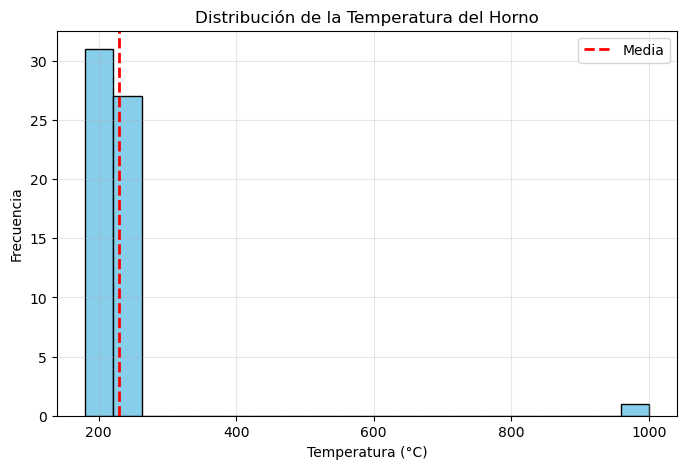

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(temp_limpia, bins=20, color='skyblue', edgecolor='black')
plt.axvline(temp_limpia.mean(), color='red', linestyle='dashed', linewidth=2, label='Media')
plt.title('Distribución de la Temperatura del Horno')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Un valor del tipo negativo no tiene significado físico como tal, debido a su incosistencia ya que el tiempo es una magnitud escalar como tal, y que en este contexto no debe ser menor a cero.

Se observa que la dsitribucion se observa fuertemente distorsionada y no uniforme con respecto a la presencia del outlier extremo de caso 1000°C, si ignoramos este error solo rondaría por los 170-250°C

In [16]:
#Ejercicio 2
def costo_produccion(temperatura):
    """
    Modela el costo de produccion por lote en funcion de la temperatura del horno.
    Parametros:
    temperatura (float): temperatura del horno en grados Celsius
    Retorna:
    float: costo estimado del lote en pesos
    """
    T_optima = 220
    costo_base = 1500
    return 0.05 * (temperatura - T_optima)**2 + costo_base

In [17]:
print({costo_produccion(220)})

{1500.0}


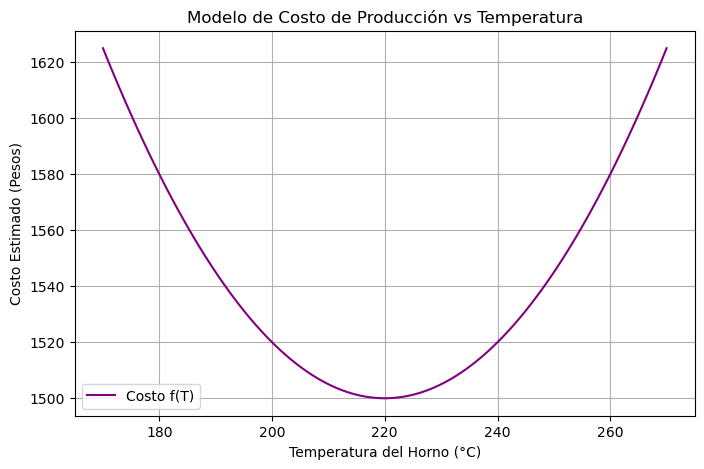

In [18]:
temperaturas = np.linspace(170, 270, 100)
costos = costo_produccion(temperaturas)

plt.figure(figsize=(8, 5))
plt.plot(temperaturas, costos, label='Costo f(T)', color='purple')
plt.title('Modelo de Costo de Producción vs Temperatura')
plt.xlabel('Temperatura del Horno (°C)')
plt.ylabel('Costo Estimado (Pesos)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
resultado_brent = minimize_scalar(costo_produccion, method='brent')
print("Resultados Método Brent")
print(f"Temperatura óptima (x): {resultado_brent.x}")
print(f"Costo mínimo (fun): {resultado_brent.fun}")
print(f"Convergió (success): {resultado_brent.success}")
print(f"Iteraciones (nit): {resultado_brent.nit}")


--- Resultados Método Brent ---
Temperatura óptima (x): 220.0000000000022
Costo mínimo (fun): 1500.0
Convergió (success): True
Iteraciones (nit): 4


In [20]:
resultado_bounded = minimize_scalar(
    costo_produccion,
    bounds=(180, 250),
    method='bounded'
)
print("Resultados Método Bounded")
print(f"Temperatura óptima (x): {resultado_bounded.x}")
print(f"Costo mínimo (fun): {resultado_bounded.fun}")
print(f"Convergió (success): {resultado_bounded.success}")
print(f"Iteraciones (nit): {resultado_bounded.nit}")


--- Resultados Método Bounded ---
Temperatura óptima (x): 220.00000000000006
Costo mínimo (fun): 1500.0
Convergió (success): True
Iteraciones (nit): 6


1) Dado la gráfica de la parabola se puede deducir que posee un mínimo gloval al ser concava hacia arriba, por lo tanto aplicar el "minimize_scalar" es justificado en este caso.
2) Ambos convergen en 220°C, lo cual se podría decir que si, además que conside con T_optima.
3) Los valores x son indenticos en términos prácticos [220°C]. es recomendado usar bounded para que no hayan daños en el horno, por eso el uso de boundede en sí.
4) requiere más iteraciones el bounded que el brent, dado el método nit que lo menciona.

In [22]:
#Ejercicio 3
comparacion = pd.DataFrame({
    'Metodo': ['brent', 'bounded'],
    'x_optimo': [resultado_brent.x, resultado_bounded.x],
    'costo_min': [resultado_brent.fun, resultado_bounded.fun],
    'iteraciones': [resultado_brent.nit, resultado_bounded.nit],
    'convergio': [resultado_brent.success, resultado_bounded.success]
    })
print("Tabla Resumen de Optimización:")
print(comparacion.to_string(index=False))

Tabla Resumen de Optimización:
 Metodo  x_optimo  costo_min  iteraciones  convergio
  brent     220.0     1500.0            4       True
bounded     220.0     1500.0            6       True


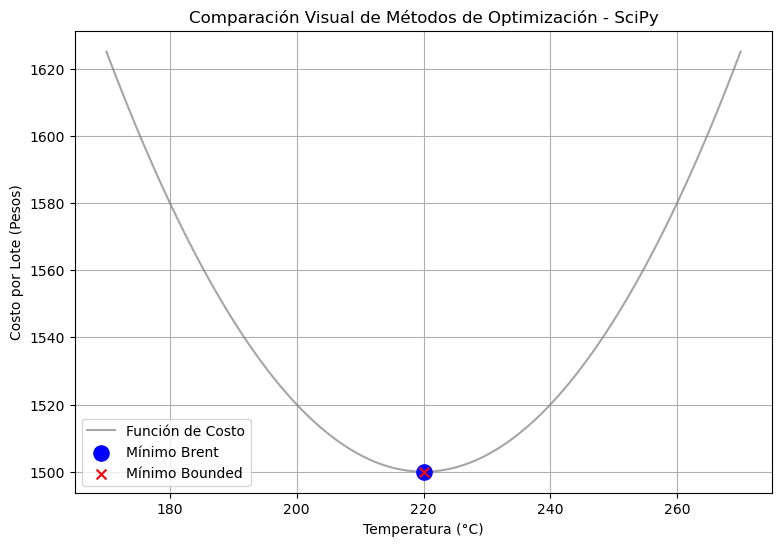

In [23]:
plt.figure(figsize=(9, 6))
plt.plot(temperaturas, costos, label='Función de Costo', color='gray', alpha=0.7)

plt.scatter(resultado_brent.x, resultado_brent.fun, color='blue', s=120, label='Mínimo Brent', marker='o', zorder=5)
plt.scatter(resultado_bounded.x, resultado_bounded.fun, color='red', s=50, label='Mínimo Bounded', marker='x', zorder=6)

plt.title('Comparación Visual de Métodos de Optimización - SciPy')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Costo por Lote (Pesos)')
plt.legend()
plt.grid(True)
plt.show()

1) Yo creo que garantizaría usa seguridad por así decirlo en terminos de lo que se evalua, de esta manera habría menos riesgos evaluativos en cuanto a la mal logración del producto en si.
2) Podría quedarse en un bucle al buscar el primer mínimo, al ser complejo (muchos valles) le va a costar encontrarlo.
3) Se tendría que ocupar otra función llamada "piecewise" que cambiaría la cuadrática por una por tramos, siendo más accesible y visualizable por así decirlo.